### Цель этого ноутбука - изучить данные о транзакциях, понять распределения признаков, выявить дисбаланс классов и найти потенциальные взаимосвязи, которые могут быть полезны для построения модели обнаружения мошенничества.

### 1. Загрузка Библиотек и Данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Настройки для визуализаций
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6) # Размер графиков по умолчанию

# %%
# --- Конфигурация ---
DATA_FOLDER = os.path.join('..', 'data') # Относительный путь к папке data
DATA_FILE = 'creditcard.csv'
DATA_PATH = os.path.join(DATA_FOLDER, DATA_FILE)
TARGET_COLUMN = 'Class' # Название целевой переменной

# --- Загрузка данных ---
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Данные успешно загружены из: {DATA_PATH}")
    print(f"Размер датасета: {df.shape}")
except FileNotFoundError:
    print(f"ОШИБКА: Файл данных не найден по пути '{DATA_PATH}'")
    df = None
except Exception as e:
    print(f"Произошла ошибка при загрузке данных: {e}")
    df = None


Данные успешно загружены из: ..\data\creditcard.csv
Размер датасета: (284807, 31)


### 2. Первичный Осмотр Данных

In [2]:
if df is not None:
    print("Первые 5 строк данных:")
    # Используем display для лучшего форматирования в Jupyter/VS Code notebooks
    from IPython.display import display
    display(df.head())

    print("\nИнформация о типах данных и пропусках:")
    df.info()

    print("\nОсновные статистические показатели:")
    # Транспонируем для лучшей читаемости при большом количестве колонок
    display(df.describe().T)

    print("\nПроверка на наличие дубликатов:")
    num_duplicates = df.duplicated().sum()
    if num_duplicates > 0:
        print(f"Обнаружено {num_duplicates} дублирующихся строк.")
        # Решение о удалении дубликатов принимается здесь (часто их удаляют)
        # df = df.drop_duplicates()
        # print("Дубликаты удалены.")
    else:
        print("Дублирующихся строк не обнаружено.")

Первые 5 строк данных:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995



Проверка на наличие дубликатов:
Обнаружено 1081 дублирующихся строк.


### 3. Анализ Целевой Переменной (`Class`)

Распределение классов:
Class
0    284315
1       492
Name: count, dtype: int64

В процентах:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


C:\Users\79103\AppData\Local\Temp\ipykernel_19388\3351364732.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=TARGET_COLUMN, data=df, palette='viridis')


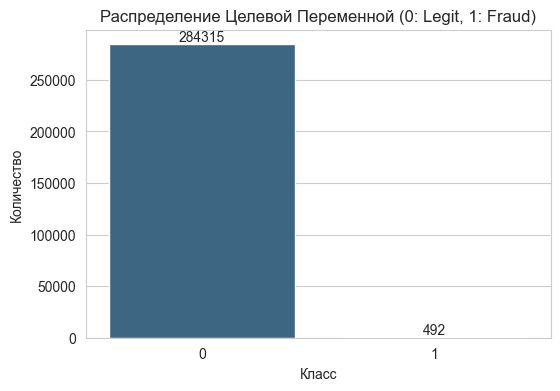


Вывод: Датасет сильно несбалансирован. Мошеннические транзакции (Класс 1) составляют всего 0.173%.
Это необходимо учитывать при выборе метрик и методов моделирования.


In [3]:
if df is not None:
    print("Распределение классов:")
    class_counts = df[TARGET_COLUMN].value_counts()
    class_percentages = df[TARGET_COLUMN].value_counts(normalize=True) * 100

    print(class_counts)
    print("\nВ процентах:")
    print(class_percentages)

    # Визуализация
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x=TARGET_COLUMN, data=df, palette='viridis')
    plt.title('Распределение Целевой Переменной (0: Legit, 1: Fraud)')
    plt.xlabel('Класс')
    plt.ylabel('Количество')
    # Добавление меток на бары
    for container in ax.containers:
        ax.bar_label(container)
    plt.show()

    print(f"\nВывод: Датасет сильно несбалансирован. Мошеннические транзакции (Класс 1) составляют всего {class_percentages.loc[1]:.3f}%.")
    print("Это необходимо учитывать при выборе метрик и методов моделирования.")


### 4. Анализ Признаков

Построение гистограмм для всех признаков...


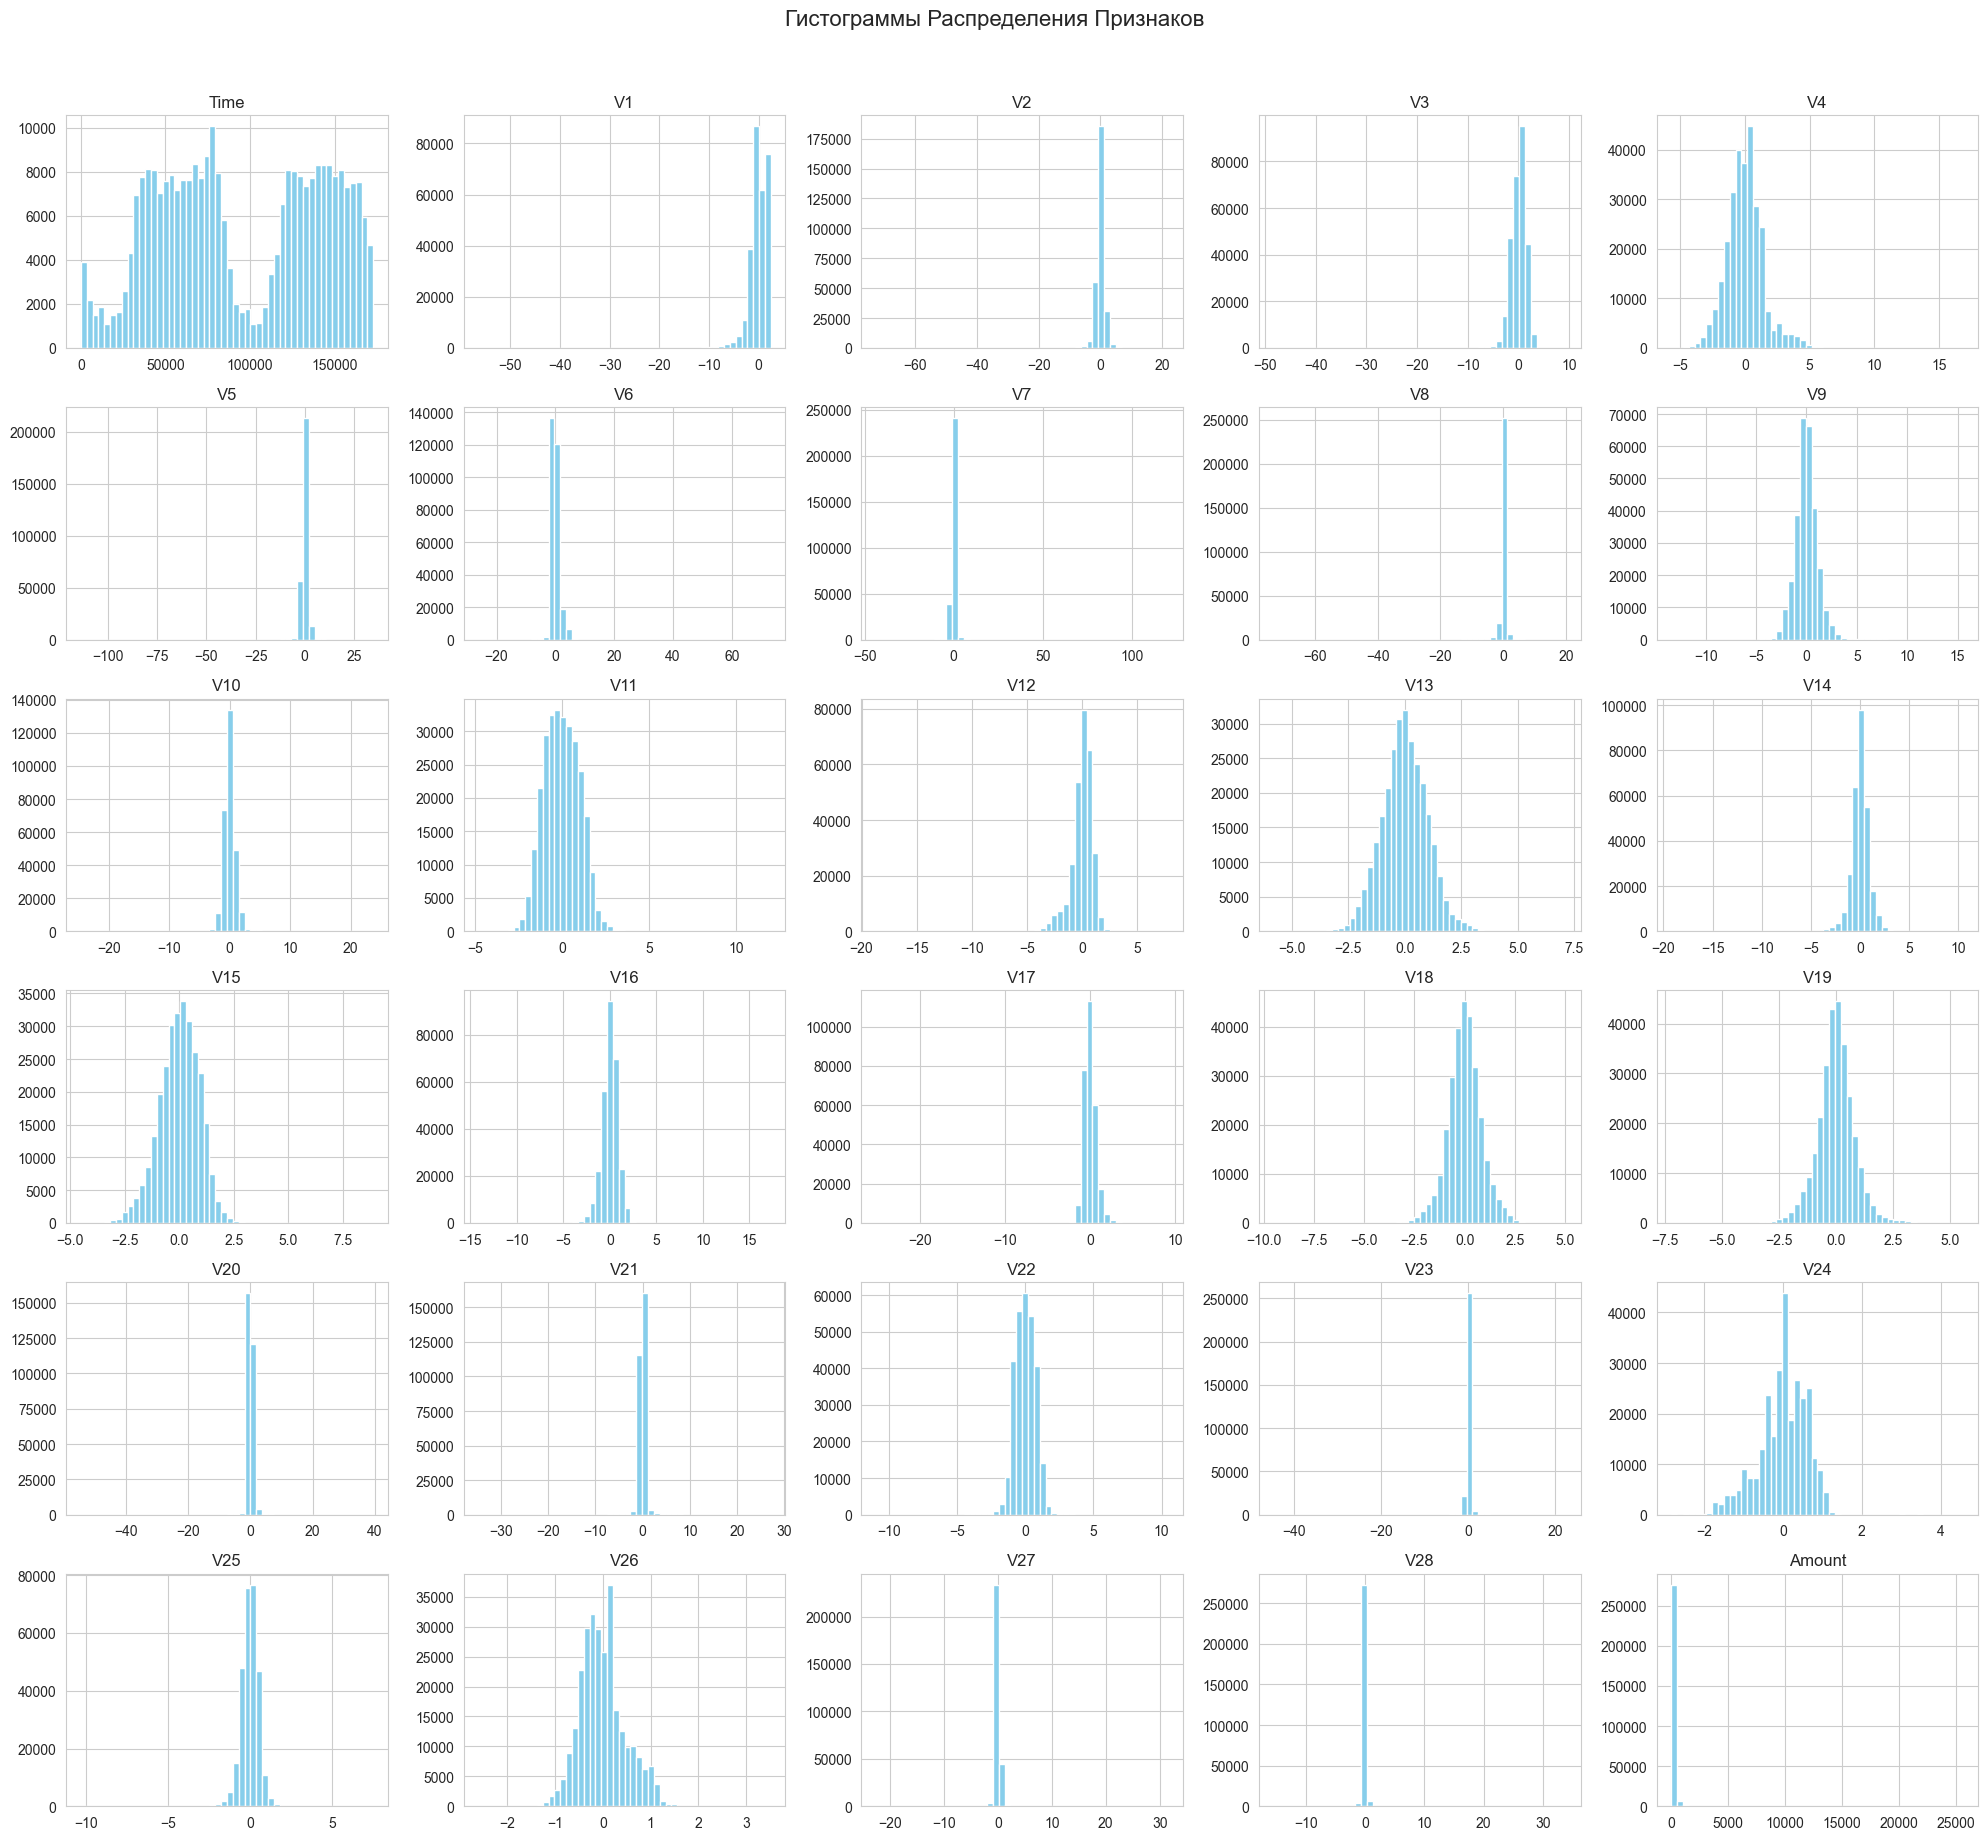


Наблюдения:
- Признак 'Time', похоже, имеет бимодальное распределение (возможно, день/ночь).
- Признак 'Amount' сильно скошен вправо (большинство транзакций на малые суммы).
- Признаки 'V1'-'V28' (результаты PCA) выглядят центрированными около нуля, но имеют разный масштаб/разброс.


In [4]:
if df is not None:
    print("Построение гистограмм для всех признаков...")
    # Исключаем целевую переменную
    features_to_plot = df.columns.drop(TARGET_COLUMN)
    df[features_to_plot].hist(figsize=(20, 18), bins=50, color='skyblue')
    plt.suptitle('Гистограммы Распределения Признаков', y=1.02, size=16)
    plt.tight_layout() # Располагаем графики плотнее
    plt.show()
    print("\nНаблюдения:")
    print("- Признак 'Time', похоже, имеет бимодальное распределение (возможно, день/ночь).")
    print("- Признак 'Amount' сильно скошен вправо (большинство транзакций на малые суммы).")
    print("- Признаки 'V1'-'V28' (результаты PCA) выглядят центрированными около нуля, но имеют разный масштаб/разброс.")

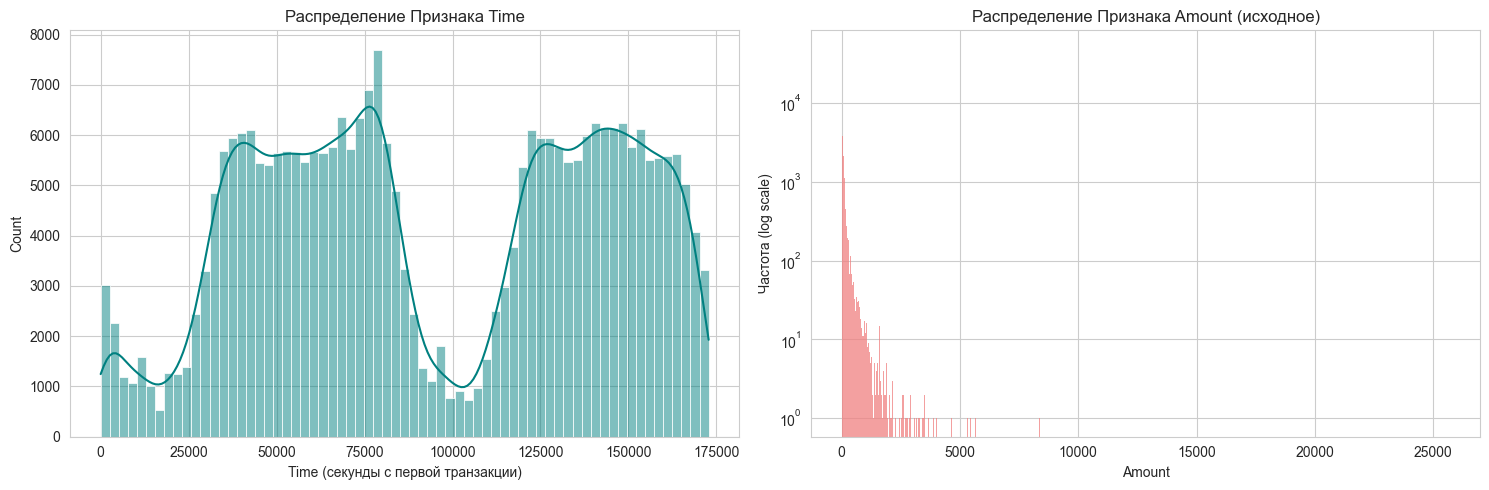

C:\Users\79103\AppData\Local\Temp\ipykernel_19388\1358048033.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['Time'], ax=axes[0], palette='viridis')
C:\Users\79103\AppData\Local\Temp\ipykernel_19388\1358048033.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['Amount'], ax=axes[1], palette='viridis', showfliers=True) # Показываем выбросы


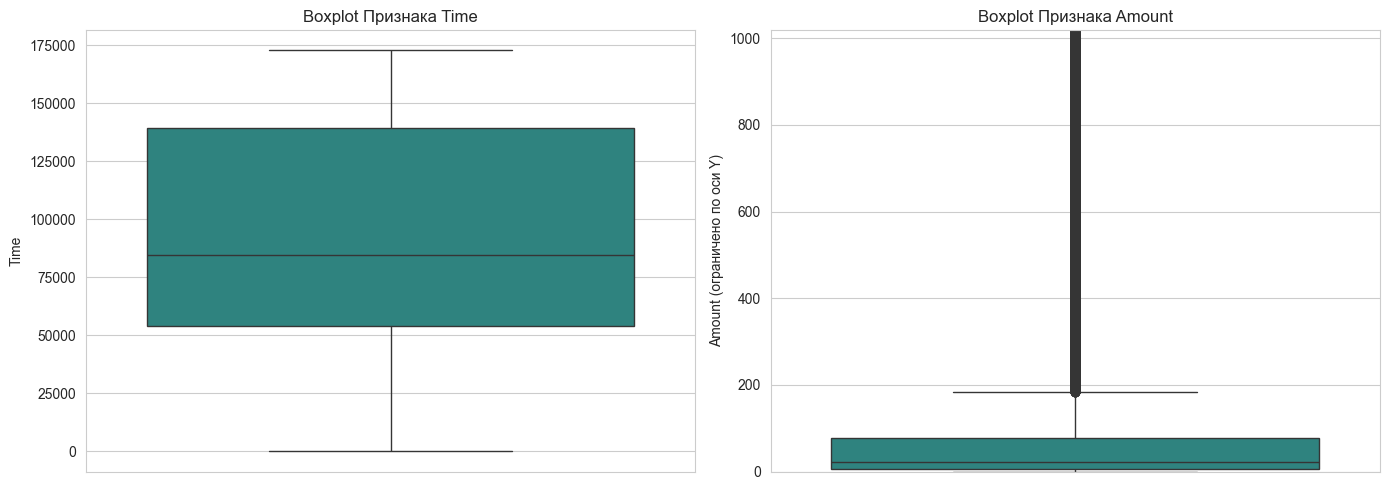

Скошенность 'Amount': 16.98

Выводы по Time и Amount:
- 'Time' покрывает примерно 2 дня транзакций (макс. ~172800 секунд).
- 'Amount' сильно скошен вправо, медиана и среднее сильно различаются. Много выбросов с большими суммами.
- Необходимо масштабирование 'Time' и 'Amount', возможно, логарифмирование 'Amount' перед масштабированием.


In [5]:
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Time
    sns.histplot(df['Time'], ax=axes[0], kde=True, color='teal')
    axes[0].set_title('Распределение Признака Time')
    axes[0].set_xlabel('Time (секунды с первой транзакции)')

    # Amount
    sns.histplot(df['Amount'], ax=axes[1], kde=False, color='lightcoral') # KDE может быть медленным и неинформативным при сильной скошенности
    axes[1].set_title('Распределение Признака Amount (исходное)')
    axes[1].set_xlabel('Amount')
    # Логарифмическая шкала для лучшей визуализации скошенного Amount
    axes[1].set_yscale('log')
    axes[1].set_ylabel('Частота (log scale)')


    plt.tight_layout()
    plt.show()

    # Box plots для оценки масштаба и выбросов
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(y=df['Time'], ax=axes[0], palette='viridis')
    axes[0].set_title('Boxplot Признака Time')

    sns.boxplot(y=df['Amount'], ax=axes[1], palette='viridis', showfliers=True) # Показываем выбросы
    axes[1].set_title('Boxplot Признака Amount')
    # Ограничим ось Y для наглядности основной части распределения Amount
    axes[1].set_ylim(0, df['Amount'].quantile(0.99)) # Показываем до 99-го перцентиля
    axes[1].set_ylabel('Amount (ограничено по оси Y)')


    plt.tight_layout()
    plt.show()

    print(f"Скошенность 'Amount': {df['Amount'].skew():.2f}")
    print("\nВыводы по Time и Amount:")
    print("- 'Time' покрывает примерно 2 дня транзакций (макс. ~172800 секунд).")
    print("- 'Amount' сильно скошен вправо, медиана и среднее сильно различаются. Много выбросов с большими суммами.")
    print("- Необходимо масштабирование 'Time' и 'Amount', возможно, логарифмирование 'Amount' перед масштабированием.")

Сравнение распределения 'Amount' по классам...


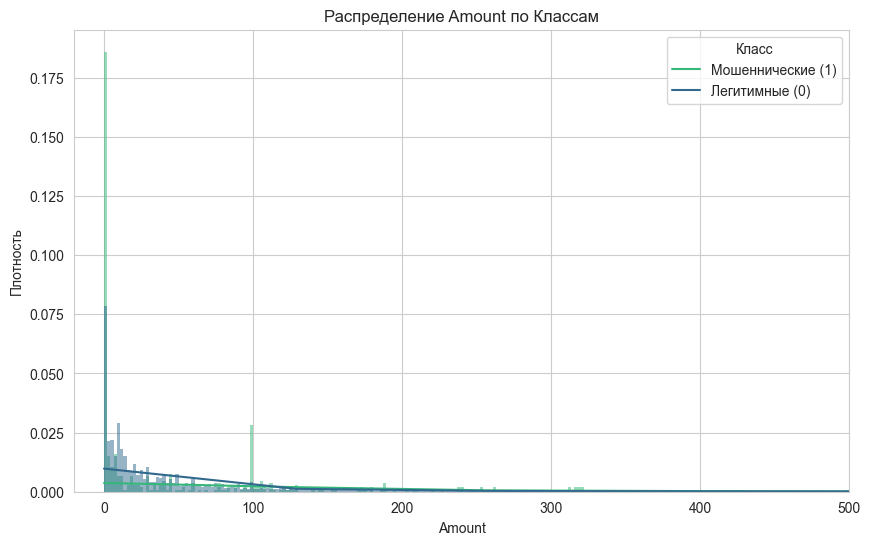

Мошеннические транзакции чаще происходят на небольшие суммы.

Сравнение распределения 'Time' по классам...


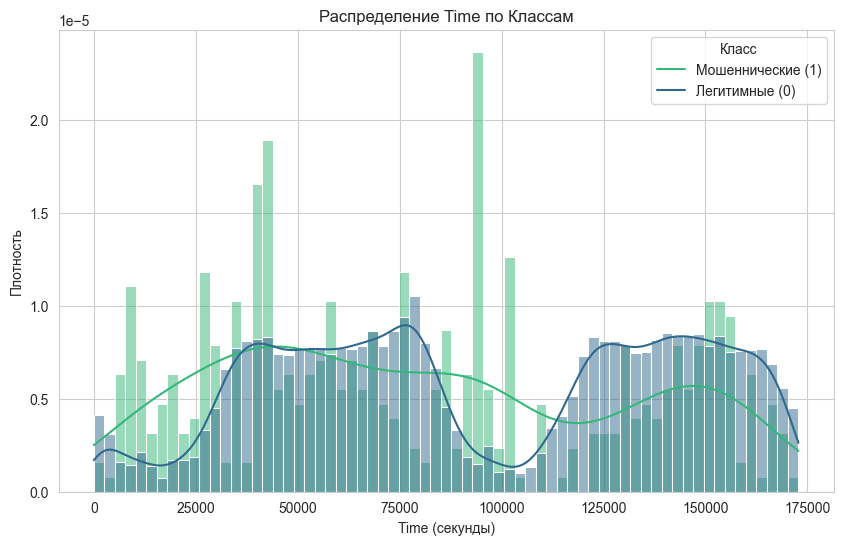

Распределения Time для мошеннических и легитимных транзакций различаются, что может быть полезно.

Сравнение распределений признаков ['V4', 'V10', 'V11', 'V12', 'V14', 'V17'] по классам...


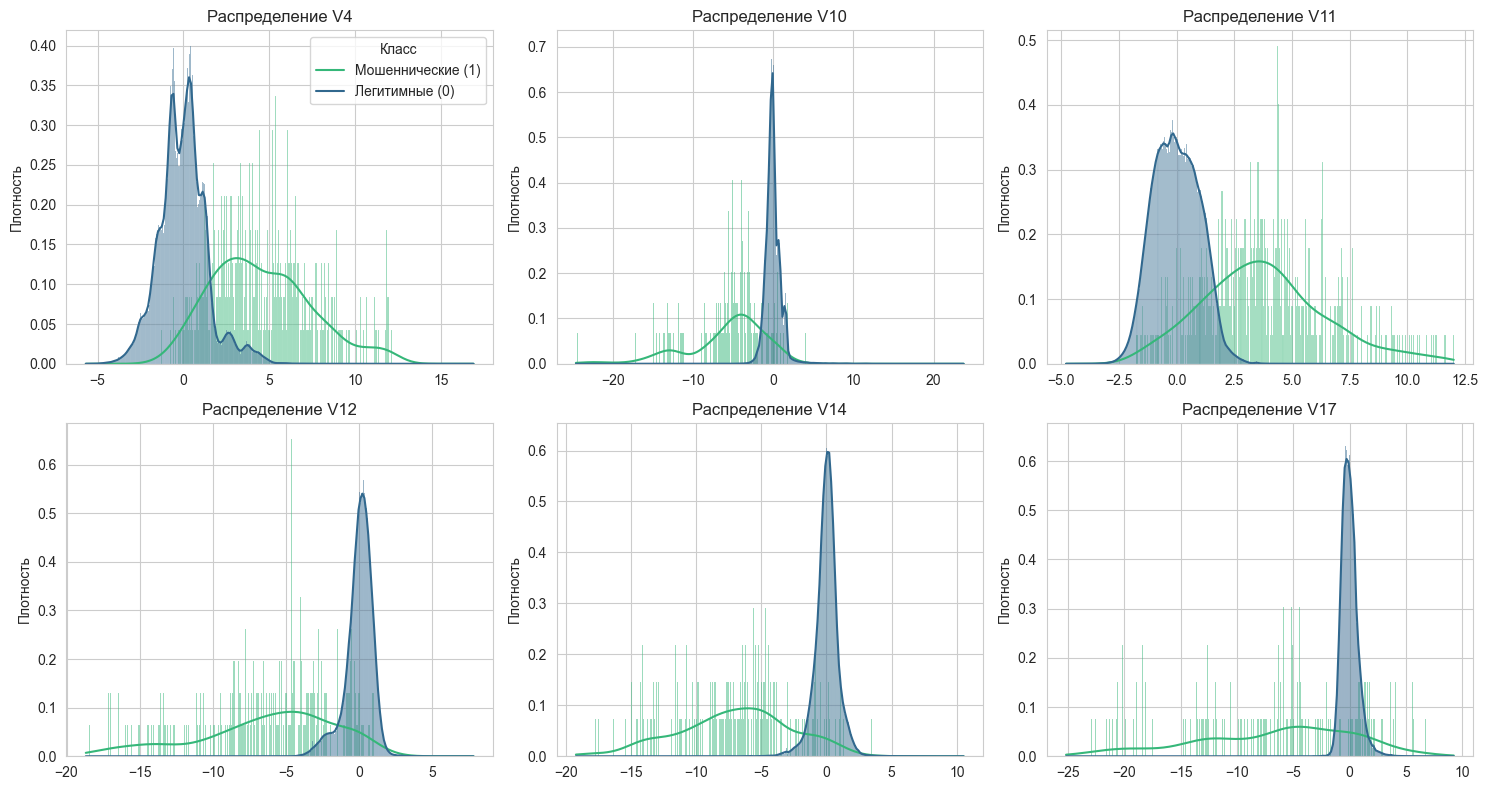

Видно, что распределения многих V-признаков заметно отличаются для разных классов.


In [7]:
if df is not None:
    # Разделяем данные для удобства
    df_fraud = df[df[TARGET_COLUMN] == 1]
    df_normal = df[df[TARGET_COLUMN] == 0]

    # Сравнение Amount
    print("Сравнение распределения 'Amount' по классам...")
    plt.figure(figsize=(10, 6))
    # Используем density для сравнения формы распределений при дисбалансе
    sns.histplot(data=df, x='Amount', hue=TARGET_COLUMN, kde=True, palette='viridis', stat='density', common_norm=False)
    plt.title('Распределение Amount по Классам')
    plt.xlim(-20, 500) # Ограничим X для наглядности основной массы
    plt.xlabel('Amount')
    plt.ylabel('Плотность')
    plt.legend(title='Класс', labels=['Мошеннические (1)', 'Легитимные (0)']) # Убедимся, что порядок верный
    plt.show()
    print("Мошеннические транзакции чаще происходят на небольшие суммы.")

    # Сравнение Time
    print("\nСравнение распределения 'Time' по классам...")
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='Time', hue=TARGET_COLUMN, kde=True, palette='viridis', stat='density', common_norm=False)
    plt.title('Распределение Time по Классам')
    plt.xlabel('Time (секунды)')
    plt.ylabel('Плотность')
    plt.legend(title='Класс', labels=['Мошеннические (1)', 'Легитимные (0)'])
    plt.show()
    print("Распределения Time для мошеннических и легитимных транзакций различаются, что может быть полезно.")

    # Сравнение некоторых V признаков (выберем те, что показали корреляцию позже)
    v_features_to_compare = ['V4', 'V10', 'V11', 'V12', 'V14', 'V17'] # Пример
    print(f"\nСравнение распределений признаков {v_features_to_compare} по классам...")
    num_plots = len(v_features_to_compare)
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
    axes = axes.flatten() # Делаем массив осей плоским для удобства итерации

    for i, feature in enumerate(v_features_to_compare):
        if i < len(axes):
             # Рисуем график. Указываем legend=False для всех, кроме первого
             add_legend = (i == 0) # Добавляем легенду только для первого графика
             sns.histplot(data=df, x=feature, hue=TARGET_COLUMN, kde=True, ax=axes[i], palette='viridis', stat='density', common_norm=False, legend=add_legend)
             axes[i].set_title(f'Распределение {feature}')
             axes[i].set_xlabel('') # Убираем подписи X для компактности
             axes[i].set_ylabel('Плотность')
             # Явно перемещаем легенду для первого графика, если нужно
             if add_legend and axes[i].get_legend() is not None:
                 axes[i].legend(title='Класс', labels=['Мошеннические (1)', 'Легитимные (0)']) # Убедись, что порядок верный # Удаляем лишние легенды


    # Скрываем пустые оси, если они есть
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    print("Видно, что распределения многих V-признаков заметно отличаются для разных классов.")

### 5. Корреляционный Анализ

Построение матрицы корреляций...


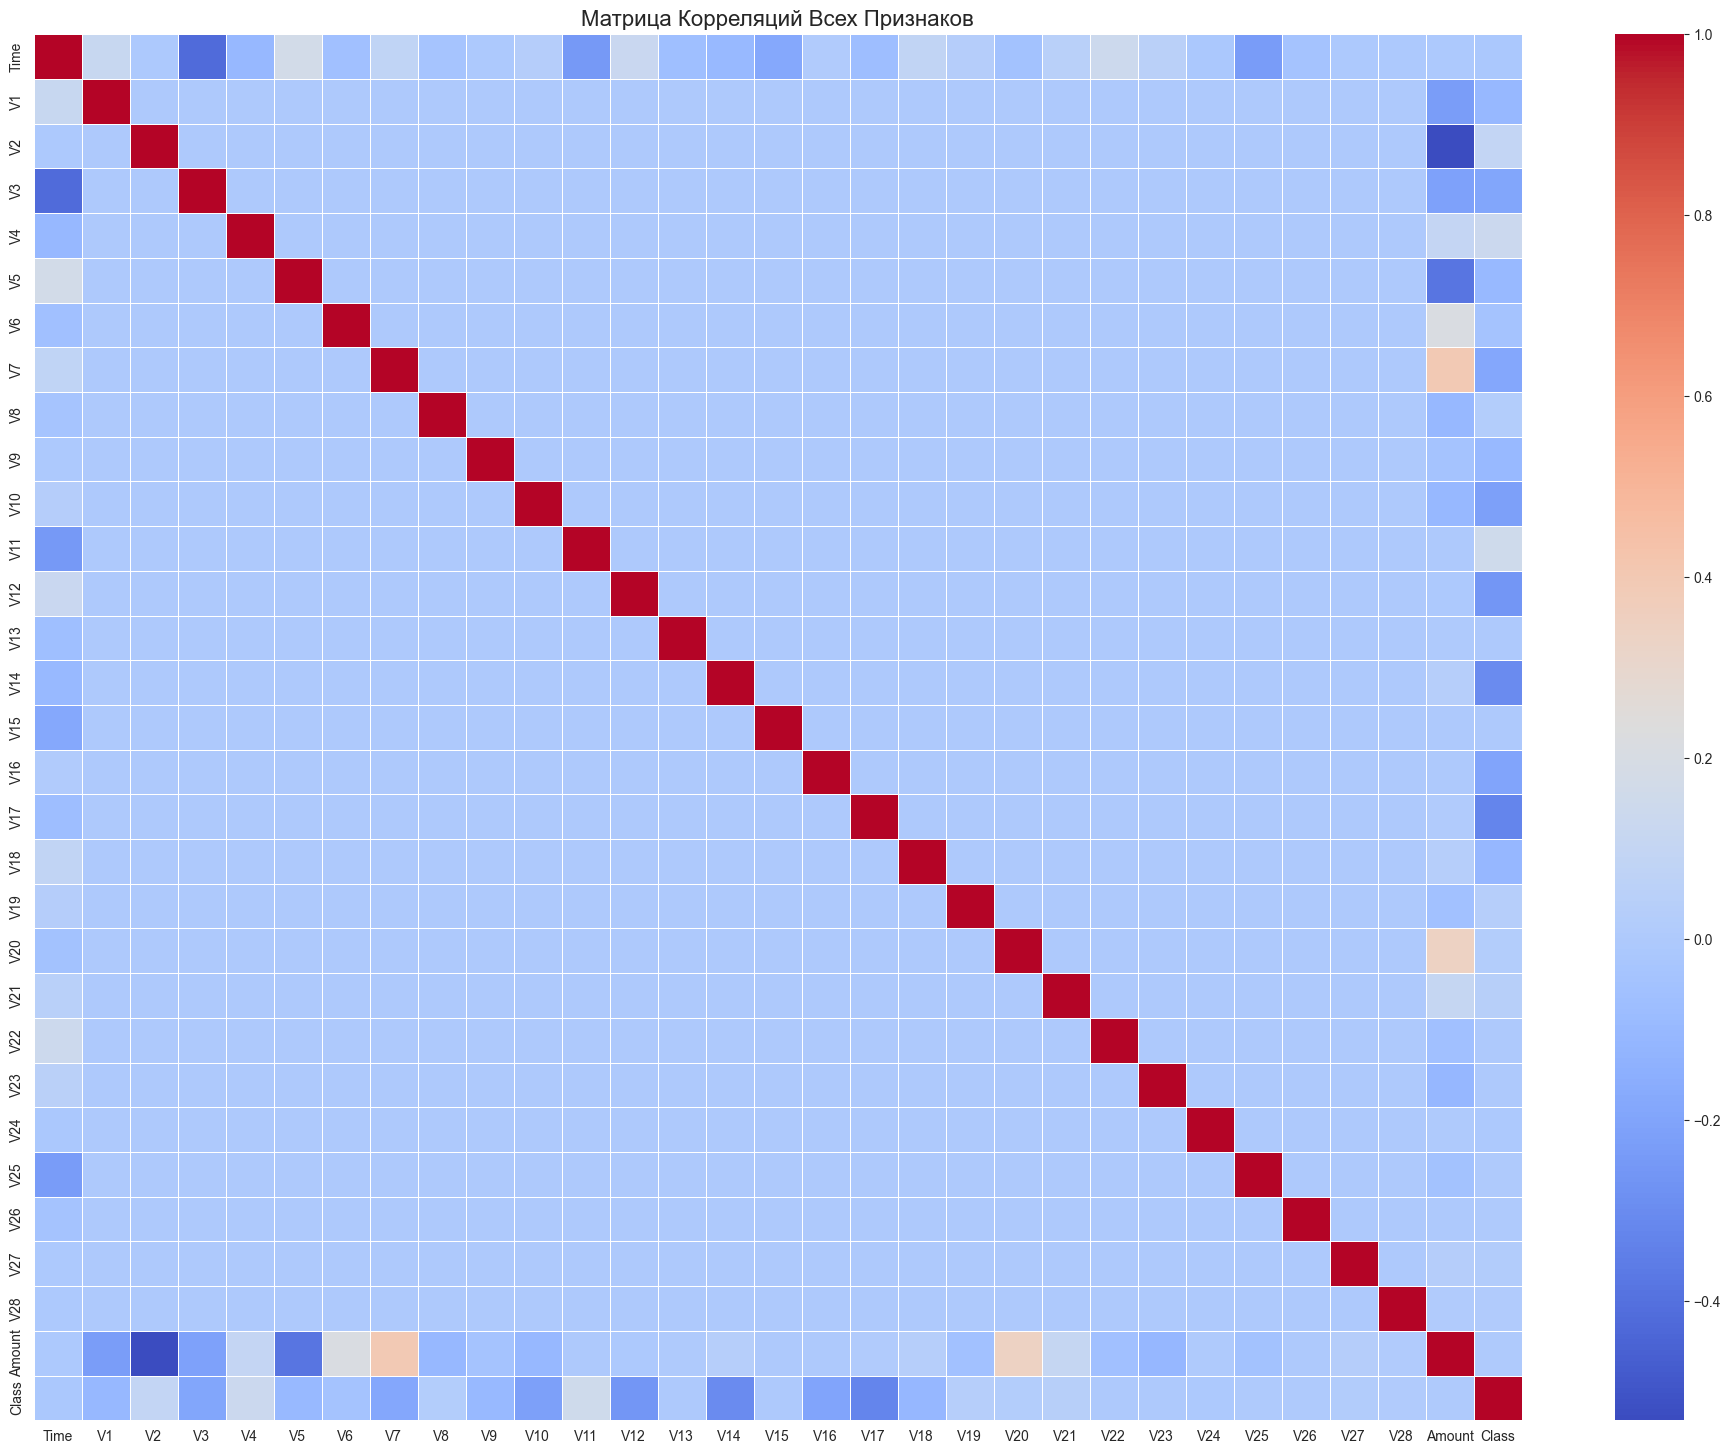


Корреляция признаков с целевой переменной (Class):


C:\Users\79103\AppData\Local\Temp\ipykernel_19388\504325087.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_correlation.values, y=class_correlation.index, palette='vlag')


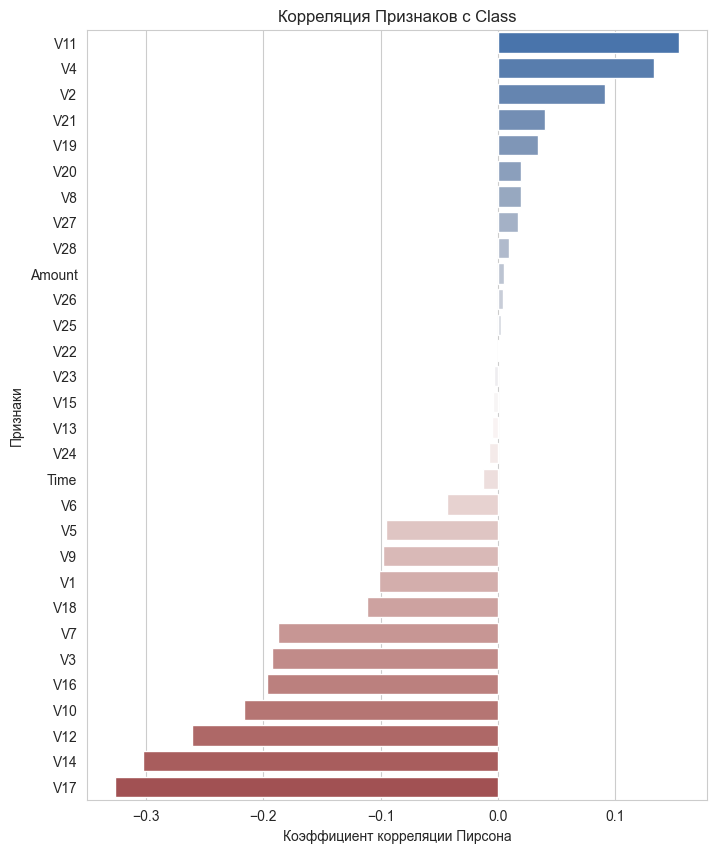


Наиболее коррелирующие признаки (по модулю):
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64

Выводы по корреляции:
- Большинство V-признаков слабо коррелируют друг с другом (ожидаемо после PCA).
- Некоторые V-признаки (V17, V14, V12, V10 - отрицательно; V11, V4, V2 - положительно) имеют наиболее заметную линейную связь с Class.
- Сильных (>0.5 или <-0.5) линейных корреляций с Class нет, что может указывать на важность нелинейных зависимостей или взаимодействий признаков.


In [8]:
if df is not None:
    print("Построение матрицы корреляций...")
    # Увеличим размер для читаемости
    plt.figure(figsize=(24, 18))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, linewidths=0.5) # annot=True слишком загромождает
    plt.title('Матрица Корреляций Всех Признаков', fontsize=16)
    plt.show()

    # Выделим корреляции с целевой переменной
    print("\nКорреляция признаков с целевой переменной (Class):")
    class_correlation = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
    # Визуализируем корреляции с классом
    plt.figure(figsize=(8, 10))
    sns.barplot(x=class_correlation.values, y=class_correlation.index, palette='vlag')
    plt.title('Корреляция Признаков с Class')
    plt.xlabel('Коэффициент корреляции Пирсона')
    plt.ylabel('Признаки')
    plt.show()

    print("\nНаиболее коррелирующие признаки (по модулю):")
    print(class_correlation.abs().nlargest(10))
    print("\nВыводы по корреляции:")
    print("- Большинство V-признаков слабо коррелируют друг с другом (ожидаемо после PCA).")
    print("- Некоторые V-признаки (V17, V14, V12, V10 - отрицательно; V11, V4, V2 - положительно) имеют наиболее заметную линейную связь с Class.")
    print("- Сильных (>0.5 или <-0.5) линейных корреляций с Class нет, что может указывать на важность нелинейных зависимостей или взаимодействий признаков.")

### 6. Выводы EDA

1.  **Дисбаланс Классов:** Данные сильно несбалансированы, класс 'Fraud' составляет менее 0.2%. Это требует использования специфических метрик (Precision, Recall, F1, PR AUC) и техник (ресемплинг, взвешивание классов) при моделировании.
2.  **Признаки `Time` и `Amount`:** Требуют масштабирования из-за разного диапазона значений. `Amount` сильно скошен, логарифмирование может быть полезным. `Time` может содержать полезную информацию о времени суток (циклические признаки).
3.  **Признаки `V1`-`V28`:** Являются результатом PCA, не имеют явной интерпретации, но многие из них показывают разное распределение для мошеннических и легитимных транзакций и коррелируют (хоть и не сильно линейно) с целевой переменной.
4.  **Корреляции:** Отсутствие сильных линейных корреляций с `Class` подтверждает, что для задачи, скорее всего, потребуются нелинейные модели (деревья решений, бустинги).
5.  **Данные чистые:** Пропусков нет, но есть дубликаты (их обработка - отдельный вопрос перед моделированием).